In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the entire Parquet file into a DataFrame
df = pd.read_parquet("../data/interim/telco_customer_churn_interim.parquet")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Bivariate/Multivariate Analysis

### MonthlyCharges and TotalCharges

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

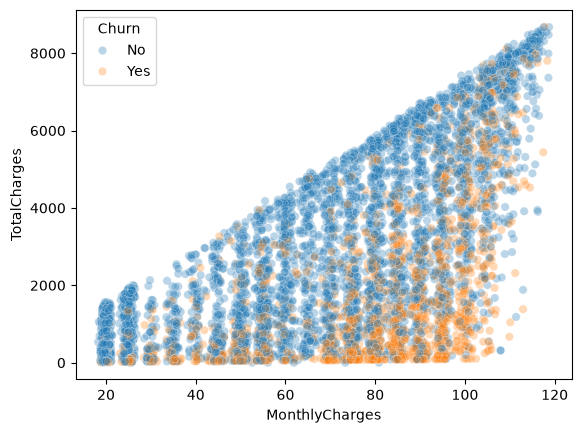

In [12]:
sns.scatterplot(data=df, x="MonthlyCharges", y="TotalCharges", hue="Churn",alpha=0.3)

1. A triangle or wedge shape.

* Every point sits below a rising diagonal edge. That edge is about 72 × `MonthlyCharges`, and 72 months is the maximum `tenure`. At a monthly charge of 118 the ceiling is about 8,500, which matches the top-right corner.
* `TotalCharges` ≈ `MonthlyCharges` × `tenure`, so this feature is mostly derived from the other two. A customer's position in the wedge is set by `tenure`: near the bottom means new, near the top edge means a long-standing customer.
* The points sitting at about `0` are the `tenure == 0` customers, whose blank `TotalCharges` was filled with `0`.

2. A fan shape. At low MonthlyCharges the vertical spread is narrow, and it widens as MonthlyCharges rises. The reason is that the same monthly price can belong to a 2-month customer or a 70-month customer. The higher the price, the larger the range of totals that tenure can produce.

3. Churn (orange) is not evenly spread. It piles up in the lower-right: high monthly charge and low total charge. That means short tenure combined with an expensive plan, such as new fibre-optic customers. The top of the wedge, long tenure, is mostly blue. Since the churner is plotted over the retained customers, the density of orange in the lower-right is probably understated.


A dense cluster near MonthlyCharges ≈ 20-30. These are phone-only customers with no internet service, which is the cheapest tier. They are mostly blue (retained) and spread across all tenures.


<Axes: xlabel='PhoneService', ylabel='MonthlyCharges'>

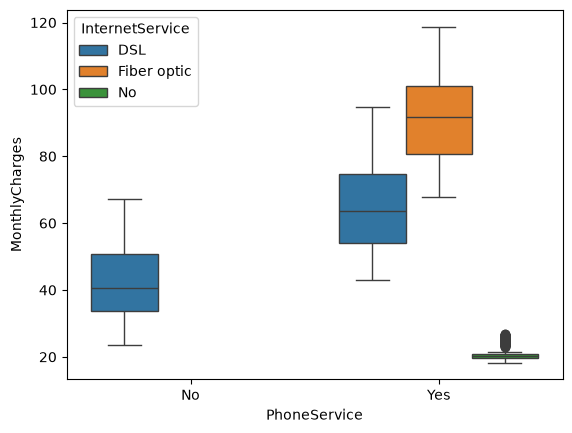

In [17]:
sns.boxplot(data=df, x="PhoneService", y="MonthlyCharges", hue="InternetService")

In [13]:
temp_df = df.loc[df['MonthlyCharges']<=30, ['PhoneService', 'InternetService', 'MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']].copy()

In [15]:
pd.crosstab(temp_df['PhoneService'], temp_df['InternetService'])

InternetService,DSL,No
PhoneService,,
No,127,0
Yes,0,1526


In [5]:
# Calculate between two specific columns
cov_pair = df['MonthlyCharges'].cov(df['TotalCharges'])
corr_pair = df['MonthlyCharges'].corr(df['TotalCharges'])
print(f"Pairwise Covariance: {cov_pair}")
print(f"Pairwise Correlation: {corr_pair}")

Pairwise Covariance: 44415.23367830183
Pairwise Correlation: 0.651173831578784


Correlation of 0.65. This is clearly positive but not near 1. If tenure were fixed, the two would be perfectly linked. Tenure varies from 0 to 72, and that is what loosens the relationship.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

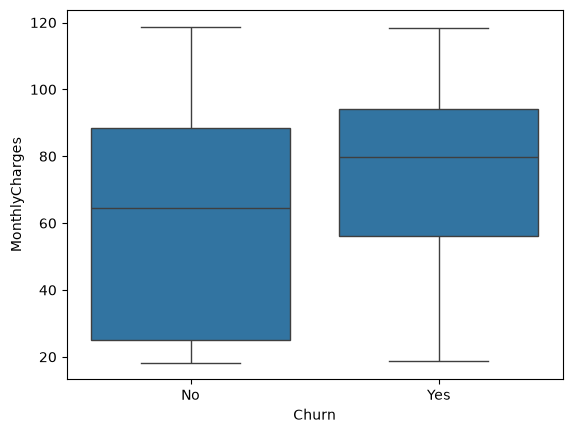

In [6]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

<Axes: xlabel='Churn', ylabel='TotalCharges'>

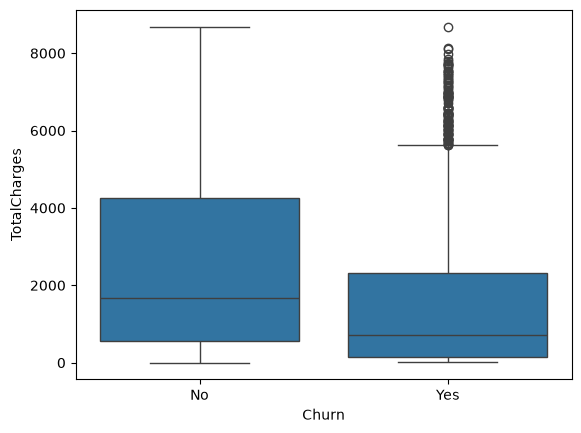

In [7]:
sns.boxplot(data=df, x="Churn", y="TotalCharges")

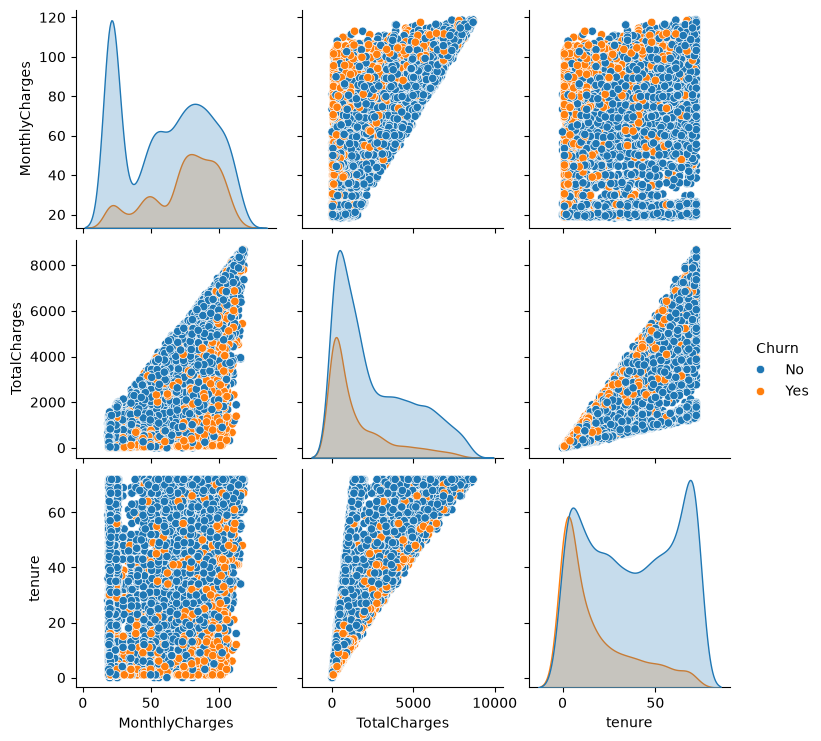

In [9]:
sns.pairplot(df, hue="Churn", vars=["MonthlyCharges", "TotalCharges", "tenure"])

On checking `MonthlyCharges` vs `tenure`, churn is higher for high `MonthlyCharges` and low  `tenure`.

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges_per_month'>

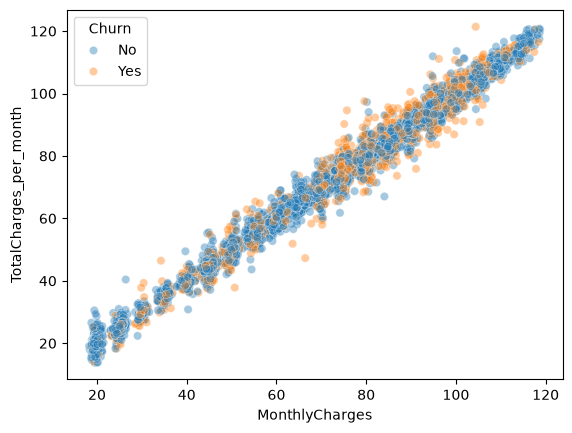

In [21]:
temp_df = df.loc[df['tenure']>0, ['MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']].copy()
temp_df['TotalCharges_per_month'] = temp_df['TotalCharges'] / temp_df['tenure']
sns.scatterplot(data=temp_df, x="MonthlyCharges", y="TotalCharges_per_month", hue="Churn", alpha=0.4)


In [22]:
temp_df['MonthlyCharges'].corr(temp_df['TotalCharges_per_month'])

np.float64(0.9962373123907751)

Good correlation between `MonthlyCharges` and `TotalCharges_per_month`

<Axes: xlabel='MonthlyCharges', ylabel='tenure'>

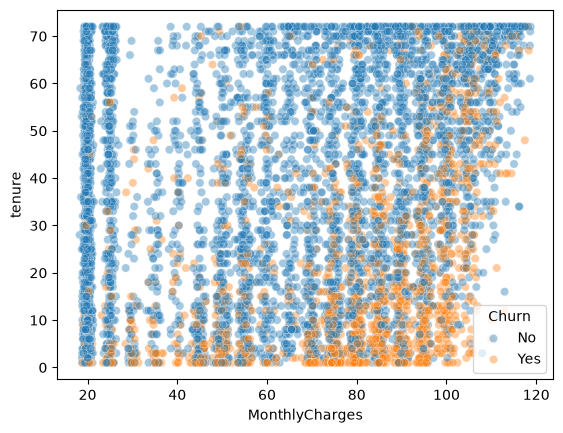

In [20]:
sns.scatterplot(data=temp_df, x="MonthlyCharges", y="tenure", hue="Churn", alpha=0.4)

> i have decided to remove the column `TotalCharges` and keep `MonthlyCharges` and `tenure` as these 2 columns covers the info in `TotalCharges` and the colinearlity is also taken care of in this way between `TotalCharges` and  `MonthlyCharges`.

In [23]:
df.drop(columns=['TotalCharges'], inplace=True, errors='ignore')

Now Check the other categorical variables.

In [25]:
df.groupby(['Contract'])['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [30]:
df["Churn_num"] = (df["Churn"] == "Yes").astype(int)
overall = df["Churn_num"].mean()          # baseline, about 0.265

In [31]:
overall

np.float64(0.2653698707936959)

In [32]:
# Check 1: churn rate + group size for one feature

summary = (
    df.groupby("Contract")["Churn_num"]
      .agg(churn_rate="mean", n="count")
      .sort_values("churn_rate", ascending=False)
)

# summary
# The mean of a 1/0 column is the proportion of 1s, so mean is the churn rate. n tells you how much evidence is behind each rate.

In [33]:
summary

,churn_rate,n
Contract,,
Month-to-month,0.427097,3875
One year,0.112695,1473
Two year,0.028319,1695


In [34]:
# Check 2: plot against the baseline

def plot_churn_rate(col, data=df):
    order = data.groupby(col)["Churn_num"].mean().sort_values(ascending=False).index
    ax = sns.barplot(data=data, x=col, y="Churn_num", order=order)   # bars = mean, whiskers = 95% CI
    ax.axhline(overall, color="red", linestyle="--", label=f"overall {overall:.1%}")
    ax.set_ylabel("Churn rate")
    ax.legend()
    plt.xticks(rotation=20)
    plt.show()

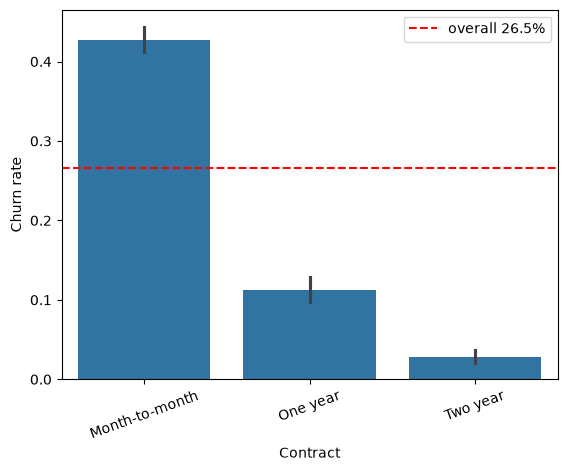

In [35]:
plot_churn_rate("Contract")

In [36]:
cat_cols = [c for c in df.select_dtypes(exclude="number").columns
            if c not in ("customerID", "Churn")] + ["SeniorCitizen"]

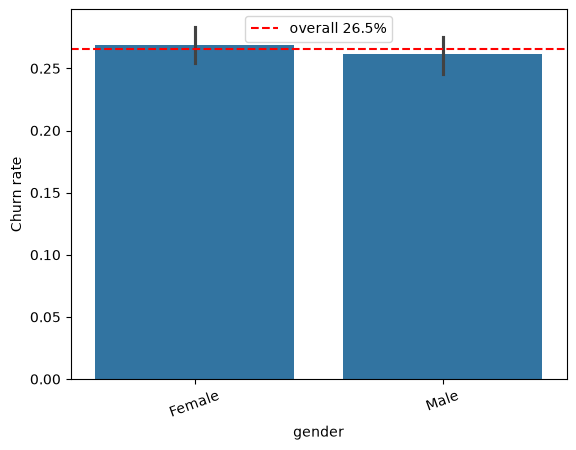

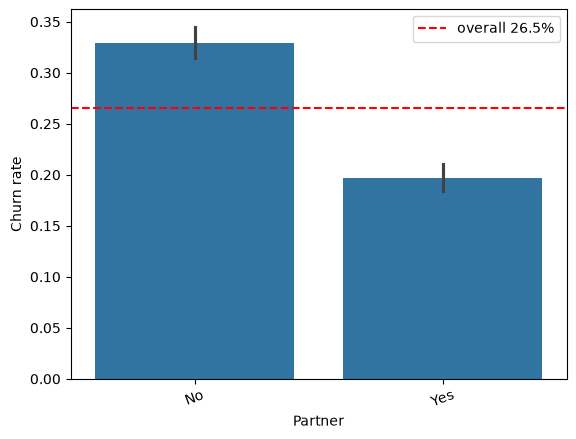

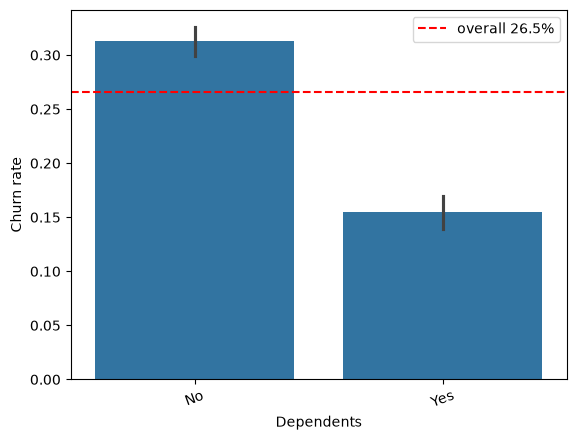

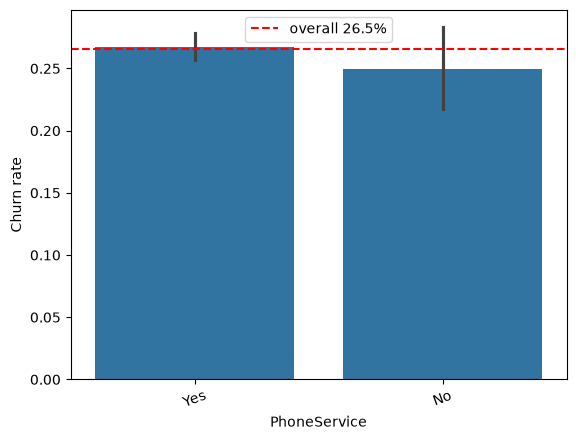

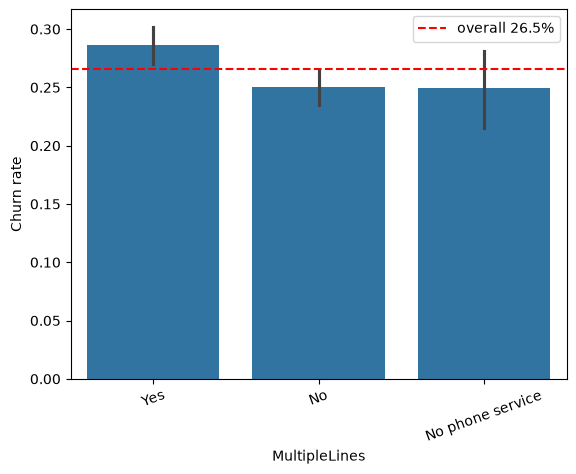

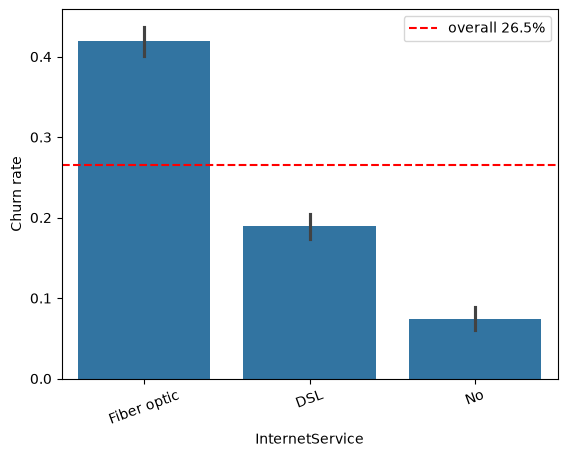

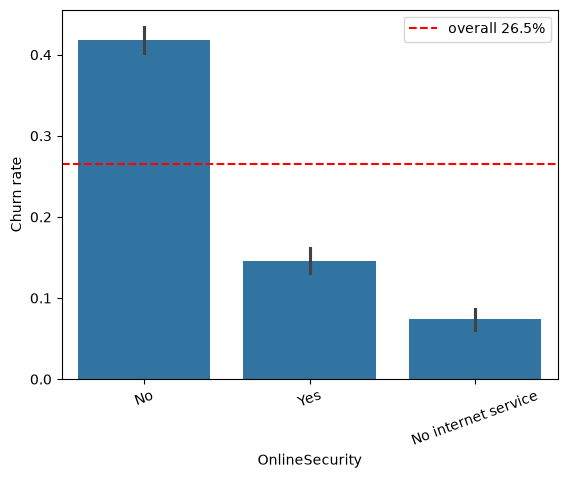

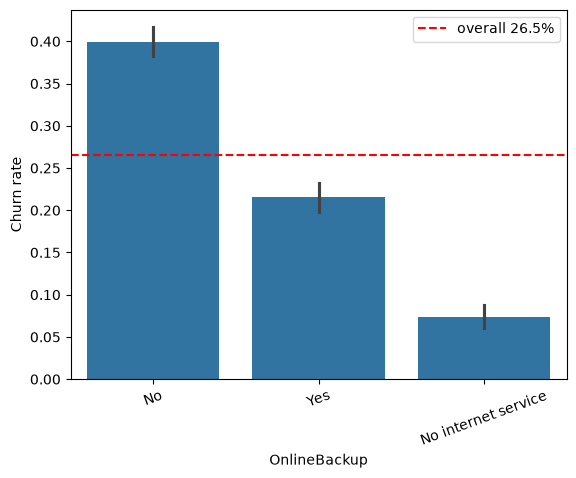

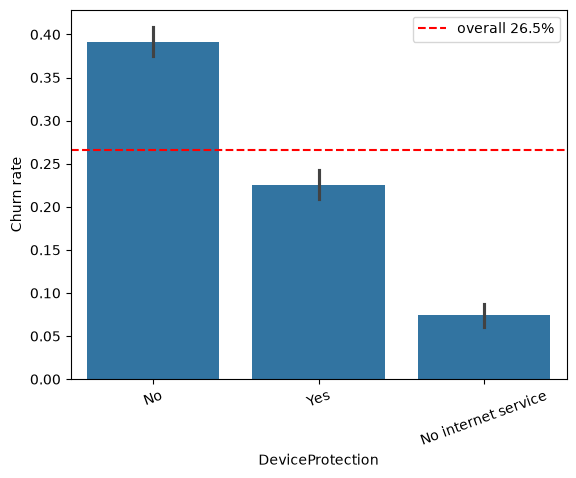

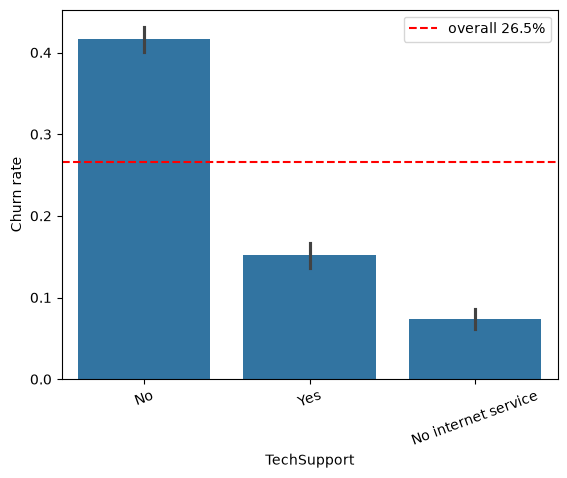

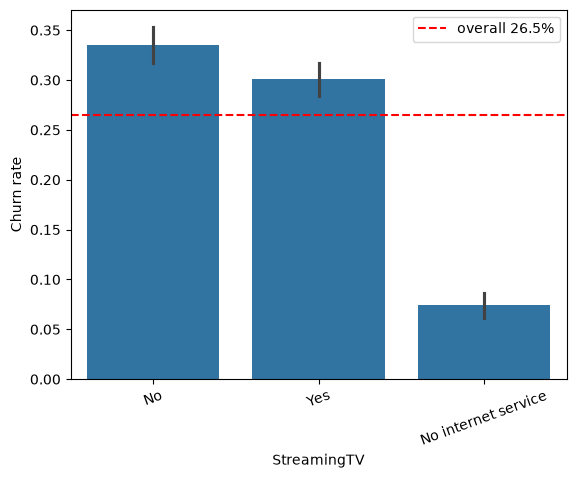

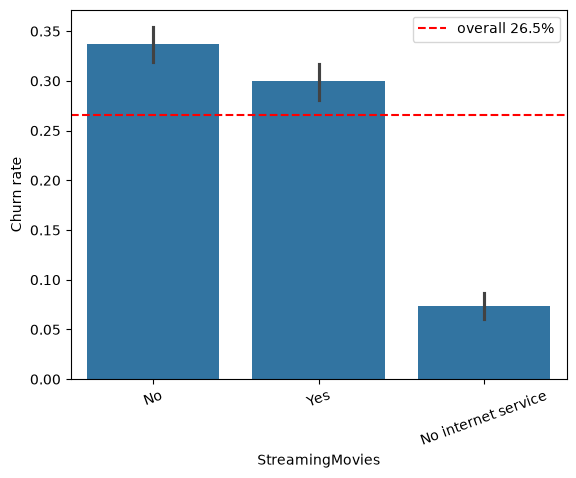

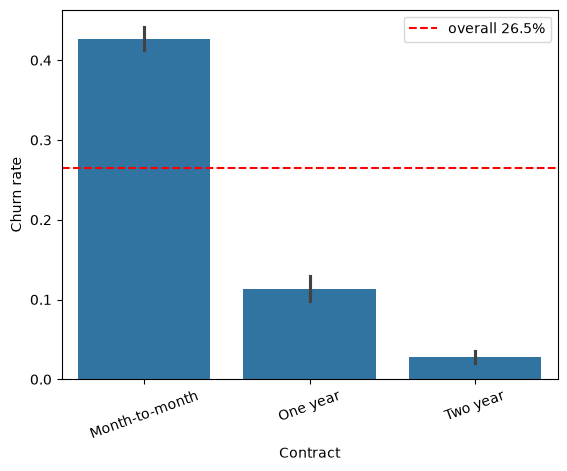

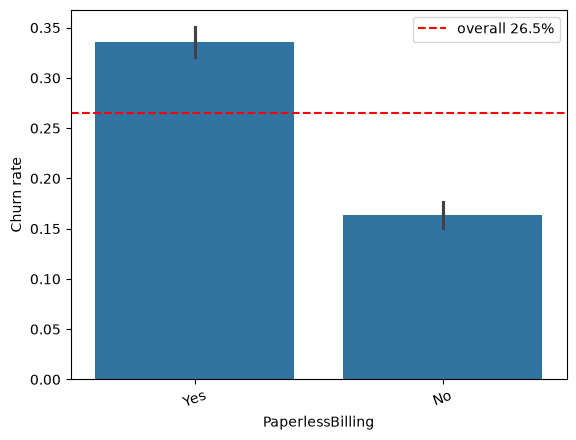

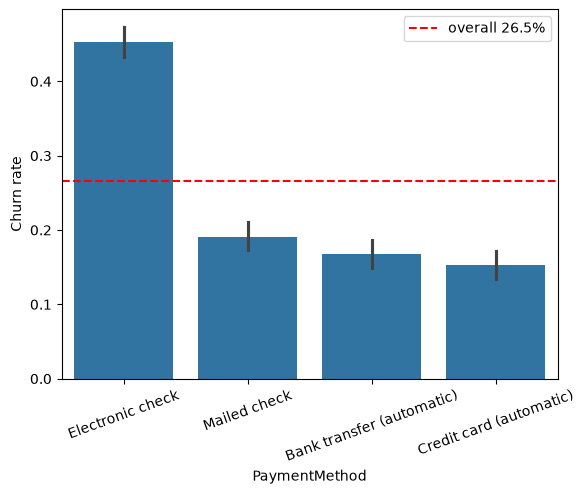

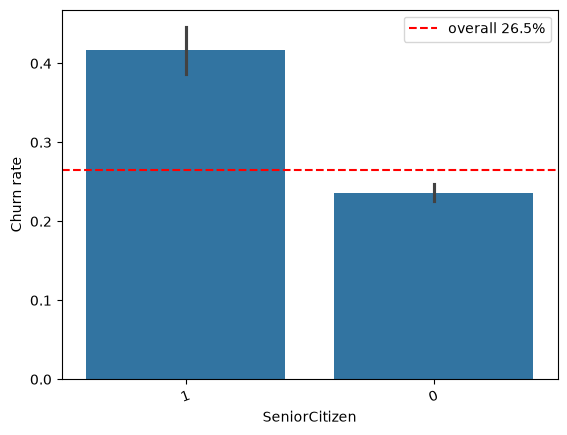

In [37]:
for col in cat_cols:
    plot_churn_rate(col)